In [5]:
import os
import re
import cv2
import numpy as np
import pandas as pd
import easyocr
import matplotlib.pyplot as plt

# Инициализируем EasyOCR
reader = easyocr.Reader(['en'], gpu=True)

# Создаем универсальную функцию для показа картинок.
# Сейчас она красиво выведет фото внутри ноутбука,
# а когда мы превратим проект в .py приложение, мы заменим её код на стандартное окно Windows одной строчкой
def show_image(image, title="Image"):
    # Переводим из формата OpenCV (BGR) в формат Matplotlib (RGB)
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(rgb_image)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [6]:
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print(os.getcwd())

D:\Projects\Click Count


In [7]:
# Crop settings in %
CROP_TOP = 10
CROP_BOTTOM = 5
CROP_LEFT = 0   # Set to 0 to avoid cutting off click numbers on the left
CROP_RIGHT = 1

# Line merging threshold (in pixels)
# If lines overlap/merge, should decrease to 10. If a single line splits into two, should increase to 30.
LINE_THRESHOLD = 20

In [8]:
# folder path
folder_path = 'data'
output_file = 'output/analyzed_data.csv'
# Если папки 'output' на компьютере ещё нет, Гит или Питон создадут её сами.
os.makedirs('output', exist_ok=True)

In [9]:
def preprocess_for_easyocr(img):
    # 1. Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. MOIRE REMOVAL (Gaussian Blur)
    # A (5,5) kernel is optimal: it removes ripple noise without making the letters blurry.
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # 3. CONTRAST ENHANCEMENT (CLAHE)
    # Extracting letters from shadows and glare.
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(blurred)

    # 4. SHARPENING (Unsharp Mask)
    # Restoring crispness to letter edges after the moire blur.
    sharpened = cv2.addWeighted(enhanced, 1.5, cv2.GaussianBlur(enhanced, (0,0), 3), -0.5, 0)

    # 5. FINAL CLEANUP (Bilateral Filter)
    # Smooth out remaining noise on flat surfaces while preserving sharp edges
    final = cv2.bilateralFilter(sharpened, 9, 75, 75)

    return final

def get_combined_lines(img_path):
    img = cv2.imread(img_path)
    if img is None: return []

    processed = preprocess_for_easyocr(img)

    # Upscale the image by 1.5x for EasyOCR
    # This is critical since letters might soften up after moire removal
    final_img = cv2.resize(processed, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LANCZOS4)

    results = reader.readtext(final_img, detail=1)
    if not results: return []

    # Line merging logic
    results.sort(key=lambda x: x[0][0][1])
    lines = []
    current_line = [results[0]]
    for i in range(1, len(results)):
        prev_y = current_line[-1][0][0][1]
        curr_y = results[i][0][0][1]
        if abs(curr_y - prev_y) < 30:
            current_line.append(results[i])
        else:
            current_line.sort(key=lambda x: x[0][0][0])
            lines.append(" ".join([res[1] for res in current_line]))
            current_line = [results[i]]
    current_line.sort(key=lambda x: x[0][0][0])
    lines.append(" ".join([res[1] for res in current_line]))

    return lines

DEBUG: Comparison for IMG-20250707-WA0003.jpg
LEFT: Original (Moire & Noise) | RIGHT: Preprocessed (Cleaned for OCR)


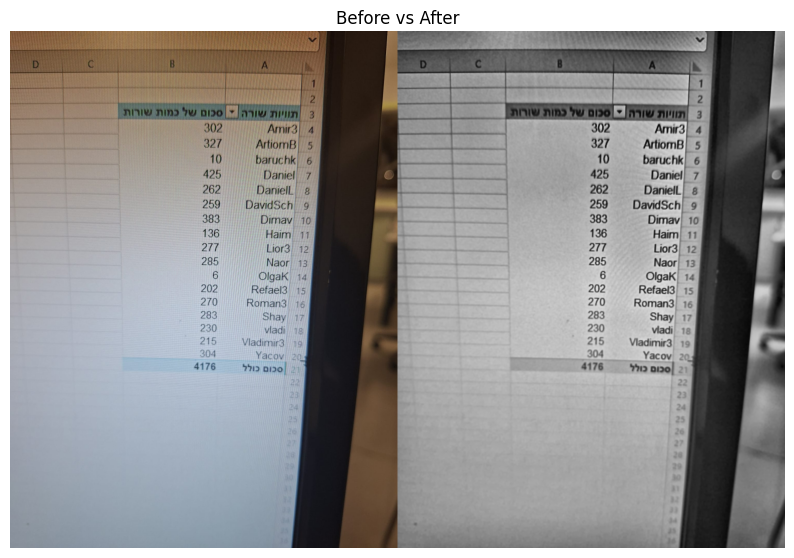

In [10]:
# --- VISUAL TEST: COMPARISON ---
test_files = sorted([f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg', '.jpeg'))])

if test_files:
    img_path = os.path.join(folder_path, test_files[0])
    original_img = cv2.imread(img_path)

    # Processing
    processed_img = preprocess_for_easyocr(original_img)

    # Resize to match dimensions for side-by-side stitching
    h, w = original_img.shape[:2]
    # Downscale for convenient preview
    scale = 0.5
    dim = (int(w * scale), int(h * scale))

    # Original (color) and Processed (grayscale after filters)
    orig_res = cv2.resize(original_img, dim)
    proc_res = cv2.resize(processed_img, dim)

    # If processed_img is single-channel (grayscale), convert to BGR for stitching
    if len(proc_res.shape) == 2:
        proc_res = cv2.cvtColor(proc_res, cv2.COLOR_GRAY2BGR)

    # Stitch two images horizontally
    comparison = np.hstack((orig_res, proc_res))

    print(f"DEBUG: Comparison for {test_files[0]}")
    print("LEFT: Original (Moire & Noise) | RIGHT: Preprocessed (Cleaned for OCR)")
    show_image(comparison, title="Before vs After")

In [11]:
# --- MAIN LOOP ---
all_data = []
test_limit = None

# Get list of all images
files = sorted([f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg', '.jpeg'))])
if test_limit: files = files[:test_limit]

print(f"🚀 Starting processing for {len(files)} files...")

for filename in files:
    # 1. Extract date from filename
    date_match = re.search(r'(\d{4})(\d{2})(\d{2})', filename)
    file_date = f"{date_match.group(1)}-{date_match.group(2)}-{date_match.group(3)}" if date_match else "Unknown"

    # print(f"📊 File: {filename} (Date: {file_date})") # Commented out to reduce repetitive output

    combined_lines = get_combined_lines(os.path.join(folder_path, filename))

    for line in combined_lines:
        # Logic to split Name and Number
        match = re.search(r'(\S+)\s+(\S+)', line)

        if match:
            p1, p2 = match.groups()
            d1 = sum(c.isdigit() for c in p1)
            d2 = sum(c.isdigit() for c in p2)

            if d1 > d2:
                count_val, name_val = p1, p2
            else:
                name_val, count_val = p1, p2

            final_count = re.sub(r'\D', '', count_val)
            final_name = re.sub(r'[^A-Za-z0-9]', '', name_val)

            if final_name and final_count:
                all_data.append({
                    'date': file_date,    # ADDED DATE
                    'file': filename,
                    'name': final_name,
                    'clicks': int(final_count)
                })

# Final export
if all_data:
    df = pd.DataFrame(all_data)

    df.to_csv(output_file, index=False, encoding='utf-16')

    print(f"\n✅ ALL DONE!")
    print(f"📁 File saved locally: {os.path.abspath(output_file)}")
    print(f"📈 Total records in database: {len(df)}")

    # Show first 5 rows for verification
    print("\nData sample:")
    print(df.head())
else:
    print("\n❌ No data was collected. Please check the logs above.")

🚀 Starting processing for 148 files...

✅ ALL DONE!
📁 File saved locally: D:\Projects\Click Count\output\analyzed_data.csv
📈 Total records in database: 3107

Data sample:
         date                     file     name  clicks
0  2025-07-07  IMG-20250707-WA0003.jpg   Amnir3     302
1  2025-07-07  IMG-20250707-WA0003.jpg   AtiomB     327
2  2025-07-07  IMG-20250707-WA0003.jpg  baruchk      10
3  2025-07-07  IMG-20250707-WA0003.jpg   Daniel     425
4  2025-07-07  IMG-20250707-WA0003.jpg  DanielL     262


In [12]:
df.head(20)

,date,file,name,clicks
0,2025-07-07,IMG-20250707-WA0003.jpg,Amnir3,302
1,2025-07-07,IMG-20250707-WA0003.jpg,AtiomB,327
2,2025-07-07,IMG-20250707-WA0003.jpg,baruchk,10
3,2025-07-07,IMG-20250707-WA0003.jpg,Daniel,425
4,2025-07-07,IMG-20250707-WA0003.jpg,DanielL,262
5,2025-07-07,IMG-20250707-WA0003.jpg,DavidSchl,259
6,2025-07-07,IMG-20250707-WA0003.jpg,Dimav,383
7,2025-07-07,IMG-20250707-WA0003.jpg,Haim,136
8,2025-07-07,IMG-20250707-WA0003.jpg,Lior3,277
9,2025-07-07,IMG-20250707-WA0003.jpg,Naor,285
